# 20_异常值处理方法-剪尾法

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本小节咱们来详细的聊聊异常值处理方法 - 剪尾法\~

#### 什么是异常值处理？为什么要处理？

**异常值**指的是在数据中**远离其他大多数数据**的那些“奇怪”的点。

比如你在做一份学生成绩统计，发现有个学生分数是 0 或 1000，那可能是漏填了、错填了，这种就可能是**异常值**。

这些异常值如果不处理，可能会影响分析结果，比如平均值被拉高，模型预测变差等。

### 剪尾法

剪尾法的意思是：

> “把数据中最小的那部分、最大那部分的极端值，**替换成一个相对合理的数**，不要直接删除。”

比如：你收集了很多人月收入的数据，大部分人月收入在 5000 到 20000 元之间，但有些极端值：

- 有个人写了 200 元（可能写错了）
- 有个人写了 100000 元（可能填错了）

我们用**剪尾法**来处理：

- 把最低的几个值（比如最小 1%）替换成第 1% 的值
- 把最高的几个值（比如最大 1%）替换成第 99% 的值

这样既保留了数据的整体结构，也避免了极端值影响分析。

## 核心原理

### 1. 剪尾法的定义

设你的数据集是一个有 $n$ 个样本的序列：


$$
X = \{x_1, x_2, \ldots, x_n\}
$$


设定一个**剪尾比例** $\alpha \in (0, 0.5)$（常用 0.05 或 0.01，即 5% 或 1%）。

然后我们找到：

- 下 $\alpha$ 分位数：$q_{\alpha}$，也叫**第** $\alpha$ **百分位数**
- 上 $(1-\alpha)$ 分位数：$q_{1-\alpha}$，也叫**第** $(1-\alpha)$ **百分位数**

然后我们做如下处理：


$$
x_i^{*} =\begin{cases}q_{\alpha}, & x_i < q_{\alpha} \\x_i, & q_{\alpha} \le x_i \le q_{1-\alpha} \\q_{1-\alpha}, & x_i > q_{1-\alpha}\end{cases}
$$


这就是剪尾法的数学定义：把太小的值替换成“第 $\alpha$ 百分位数”，太大的值替换成“第 $1-\alpha$ 百分位数”。

### 2. 剪尾与截断的区别

| 方法 | 名称 | 说明 |
|-|-|-|
| Winsorizing（剪尾） | 替换 | 把极端值**替换**为边界值 |
| Trimming（截断） | 删除 | 把极端值**直接删除** |

剪尾更温和一些，适合不想删数据的情况。

### 3. 举个例子

假设你有如下数据（10个数）：

原文参考输出或命令说明（无需在 Python 内核执行）：

```text
[10, 12, 14, 15, 16, 18, 20, 25, 100, 150]
```

我们设定剪尾比例 $\alpha = 0.1$（即 10%）

- 第 10% 分位数：排好序后第一个数，$q_{0.1} = 11$（假设线性插值得来）
- 第 90% 分位数：$q_{0.9} = 90$

剪尾后变成：

原文参考输出或命令说明（无需在 Python 内核执行）：

```text
[11, 12, 14, 15, 16, 18, 20, 25, 90, 90]
```

- 10 → 11（被剪尾）
- 100 和 150 → 都变成 90（被剪尾）

## 剪尾法的算法流程

我们以一维数组为例，来分步骤说明：

**步骤一：确定剪尾比例 α**

- 常用：α = 0.01（1%剪尾）、0.05（5%剪尾）

**步骤二：计算上下分位数**

- 排序你的数据集：$X_{\text{sorted}}$
- 找出：

  - 第 $\alpha$ 分位数（$q_{\alpha}$）
  - 第 $1 - \alpha$ 分位数（$q_{1 - \alpha}$）

这两个分位数可以用分位数公式来计算：


$$
q_{\alpha} = X_{\text{sorted}}[\lceil n \cdot \alpha \rceil]
$$


$$
q_{1 - \alpha} = X_{\text{sorted}}[\lfloor n \cdot (1 - \alpha) \rfloor]
$$


**步骤三：替换极端值**

对每个数据 $x_i$ 进行如下处理：

- 如果 $x_i < q_{\alpha}$，则用 $q_{\alpha}$ 替代
- 如果 $x_i > q_{1-\alpha}$，则用 $q_{1-\alpha}$ 替代
- 否则保留 $x_i$ 不变

**步骤四：输出新的剪尾后数据**

数据中最小和最大极值已被“压缩”，极端值对均值等统计量的影响大大降低。

## 完整案例

### 1. 案例背景

- **场景**：某公司人力资源部分析员工月薪分布，希望剔除或缓和极端异常值对统计指标（如均值、方差）的影响，以获得更稳定的薪酬水平分析结果。
- **数据**：共 1,010 名「员工」月薪，正常员工月薪服从均值 6,000 元、标准差 1,200 元的正态分布；为了模拟极端情况，额外加入 5 个极端偏低值（300–700 元）和 5 个极端偏高值（20,000–30,000 元）。

#### 整体结构

1. 构造并展示原始数据
2. 计算分位数（1% 和 99%）
3. 应用剪尾法
4. 展示剪尾前后分布对比
5. 输出分位数结果
6. 算法拆解与公式推导
7. 该案例下剪尾法的优缺点及优选场景讨论

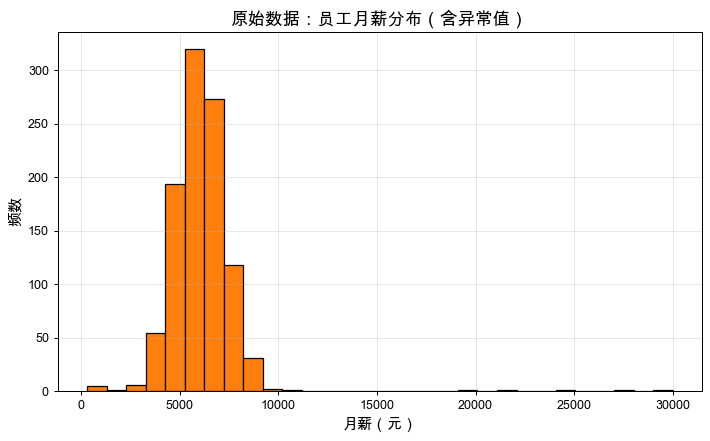

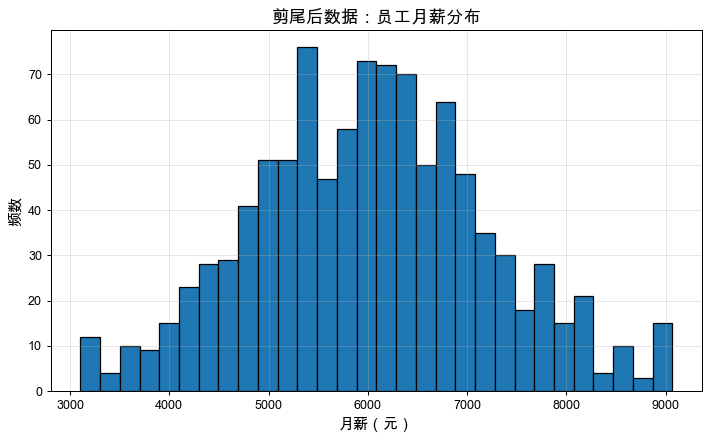

1% 分位数     3104.516290
99% 分位数    9068.521018
dtype: float64


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. 构造模拟数据：员工月薪（单位：元）
np.random.seed(42)
normal_salaries = np.random.normal(loc=6000, scale=1200, size=1000)
outliers_low  = np.array([300, 400, 500, 600, 700])
outliers_high = np.array([20000, 22000, 25000, 28000, 30000])
salaries = np.concatenate([normal_salaries, outliers_low, outliers_high])
df = pd.DataFrame({'salary': salaries})

# 2. 可视化：原始数据分布
plt.figure(figsize=(8, 5))
plt.hist(df['salary'], bins=30, color='tab:orange', edgecolor='black')
plt.title('原始数据：员工月薪分布（含异常值）', fontsize=14)
plt.xlabel('月薪（元）', fontsize=12)
plt.ylabel('频数', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 3. 计算 1% 和 99% 分位数
alpha   = 0.01
lower_q = df['salary'].quantile(alpha)
upper_q = df['salary'].quantile(1 - alpha)

# 4. 剪尾：替换极端值
df['salary_winsorized'] = df['salary'].clip(lower=lower_q, upper=upper_q)

# 5. 可视化：剪尾后数据分布
plt.figure(figsize=(8, 5))
plt.hist(df['salary_winsorized'], bins=30, color='tab:blue', edgecolor='black')
plt.title('剪尾后数据：员工月薪分布', fontsize=14)
plt.xlabel('月薪（元）', fontsize=12)
plt.ylabel('频数', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 6. 输出分位数
quantiles = pd.Series({'1% 分位数': lower_q, '99% 分位数': upper_q})
print(quantiles)

### 2. 代码每一步骤详解

#### 构造模拟数据

- 使用 `np.random.normal(loc=6000, scale=1200, size=1000)` 生成 1,000 个近似正态分布的月薪数据（均值 6,000、标准差 1,200）。
- 手动添加 5 个极低值和 5 个极高值，以模拟真实场景中可能出现的**录入错误**或**极端岗位**数据。
- 最终数据长度：1,010 条。

#### 原始数据分布可视化

- 使用 `matplotlib.pyplot.hist` 绘制直方图。
- 从直方图可以看到：大多数员工月薪集中在 3,000–9,000 元区间，但在 20,000 元以上存在明显尖峰。

![原文参考图，当前结果见代码输出](attachments/img_008.png)

#### 计算分位数

- 设剪尾比例 $\alpha=1%$（典型值也可取 5%）。
- 使用 Pandas 的 `quantile()` 方法分别计算第 1% 分位数 $q_{0.01}$ 和第 99% 分位数 $q_{0.99}$。
- 这两个值对应「将被替换的边界」。

#### 应用剪尾法

- 原理：


$$
x_i^* =\begin{cases}q_{\alpha}, & x_i < q_{\alpha} \\x_i, & q_{\alpha} \le x_i \le q_{1-\alpha} \\q_{1-\alpha}, & x_i > q_{1-\alpha}\end{cases}
$$


- 在 Pandas 中直接用 `clip(lower=lower_q, upper=upper_q)` 即可完成替换操作：

  - 小于 $q_{0.01}$ 的值全部变成 $q_{0.01}$
  - 大于 $q_{0.99}$ 的值全部变成 $q_{0.99}$

#### 剪尾后数据分布可视化

- 同样用直方图展示处理后的分布。
- 主体分布几乎不变，但尾部被“钝化”，均值和方差受极端点干扰大幅减少。

![原文参考图，当前结果见代码输出](attachments/img_009.png)

#### 分位数结果

打印出的第 1% 和第 99% 分位数分别是：

原文参考输出或命令说明（无需在 Python 内核执行）：

```text
1% 分位数     3104.516290
99% 分位数    9068.521018
```

说明：

- 所有低于 3,104.52 元的观测值都被“抬高”到 3,104.52 元
- 所有高于 9,068.52 元的观测值都被“压低”到 9,068.52 元

### 3. 剪尾法公式与原理回顾

1. **分位数定义**

   - 第 $\alpha$ 分位数 $q_{\alpha}$：有 $\alpha \times 100%$ 的数据不大于它。
   - 第 $(1-\alpha)$ 分位数 $q_{1-\alpha}$：有 $(1-\alpha)\times 100%$ 的数据不大于它。
2. **剪尾替换公式**


$$
x_i^{*} =\begin{cases}q_{\alpha}, & x_i < q_{\alpha}, \\x_i, & q_{\alpha} \le x_i \le q_{1-\alpha}, \\q_{1-\alpha}, & x_i > q_{1-\alpha}.\end{cases}
$$


1. **为何降低极端影响**

   - 极端值对均值和方差的贡献通常是与其距离有关，距离越远贡献越大。
   - 剪尾后，所有尾部观测统一成边界分位数，因此最大距离被限幅。

---

### 4. 优缺点分析与适用场景

**优点**：

- **保留全部样本**：不像截断法直接删除数据，剪尾法仅“压平”极端值，对样本总量零损耗。
- **减少统计偏移**：在均值、方差等敏感指标上，将极端点的拉动效应减到最小。
- **简单易实现**：通过计算分位数和调用一次 `clip` 即可，且无需复杂参数调优。
- **模型鲁棒性提升**：后续建模时，异常点不至于成为影响模型收敛或预测精度的大牛刀。

**缺点**：

- **信息损失**：将所有尾部值映射为同一边界数值，细粒度信息消失；若这些极端点本身含有业务价值，则被“钝化”后丢失。
- **分布形状改变**：原本可能长尾分布，经过剪尾，尾部形态被截断或变平，影响分布假设；若后续需分析尾部行为（如风险控制），不宜使用。
- **边界选择主观**：剪尾比例 $\alpha$ 需人工指定，不同 $\alpha$ 对结果影响较大；如果设得不当，可能过度压平或不足以缓和异常。

**适用场景**：

- **关心总体指标**：例如财务报表中关心平均成本、平均收益，而非个别异常天的指标。
- **数据呈长尾但极端点非重点**：营销数据、电商客户消费金额，经常是长尾分布，但极端高价订单对整体均值拉高须处理。
- **建模前预处理**：线性模型、K-Means 聚类、PCA 等对异常值敏感的算法，剪尾能使训练更稳定。
- **样本不足不宜删除**：当数据量本来就小，删除异常值会造成样本量显著减少，剪尾提供了替代方案。

## 总结

在实际应用中，建议结合业务需求合理选取 $\alpha$，并与其它异常值处理方法（如 IQR 法、Z-Score 法）进行对比，确保处理方案既符合统计学严谨性，又满足业务可解释性。